In [1]:
# -*- coding: utf-8 -*-
"""Fomae: Cross-validation analysis for MSI data."""

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
np.random.seed(1337)
import os
import h5py
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import torch
import pandas as pd
import time
import nibabel as nib

Cd = os.getcwd()
Bd = os.path.dirname(Cd)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
    }
)

def discrete_cmap(N, base_cmap=None):
    base = plt.cm.get_cmap(base_cmap)
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)

def Image_Distribution(V,xLoc,yLoc):
    col = max(np.unique(xLoc))
    row = max(np.unique(yLoc))
    Myimg = np.zeros((col,row))
    for i in range(len(xLoc)):
        Myimg[xLoc[i]-1, yLoc[i]-1] = V[i]
    return Myimg

def Correlate_Cluster_MSI(cluster_id,Labels,MSI_D,Peak_Indx,ZCoord_cv,XCoord_cv,YCoord_cv):
    Kimg = Labels==cluster_id
    Kimg = Kimg.astype(int)
    MSI_CleanPeaks = MSI_D[:,Peak_Indx[:]]
    Corr_Val =  np.zeros(len(Peak_Indx))
    
    for i in range(len(Peak_Indx)):
        Corr_Val[i] = stats.pearsonr(Kimg,MSI_CleanPeaks[:,i])[0]
    id_mzCorr = np.argmax(Corr_Val)
    rank_ij =  np.argsort(Corr_Val)[::-1]
    return Corr_Val, rank_ij, MSI_CleanPeaks

def Get_3Dmz_nifti(MSI_CleanPeaks,mz_Peak,XCoord_cv,YCoord_cv,ZCoord_cv,directory):
    mzSections = np.unique(ZCoord_cv)
    Vol_mz = np.zeros((200,200,len(mzSections)))
    nSections = len(mzSections)
    directory_NIFT = directory + '//mz_Vol//Training'
    if not os.path.exists(directory_NIFT):
        os.makedirs(directory_NIFT)
    for Zsec in range(len(mzSections)):
        ij_r = np.argwhere(ZCoord_cv == mzSections[Zsec])
        indx = ij_r[:,0]
        xLoc = XCoord_cv[indx]
        yLoc = YCoord_cv[indx]
        MSI_2D = np.squeeze(MSI_CleanPeaks[indx])
        for idx in range(len(xLoc)):
            Vol_mz[xLoc[idx]-1, yLoc[idx]-1,Zsec] = MSI_2D[idx]  

    I_nii = nib.Nifti1Image(Vol_mz,affine=np.eye(4))
    nib.save(I_nii,directory_NIFT +'//mz_' + str(mz_Peak) + '.nii')

def get_EncFeatures(Latent_z,Train_idx,myZCoord,xLocation,yLocation,directory,order):
    myzSections = np.unique(myZCoord)
    ndim = Latent_z.shape[1]
    for zr in range(len(Train_idx)):
        ij_r = np.argwhere(myZCoord == myzSections[zr])
        indx = ij_r[:,0]
        xLoc = xLocation[indx]
        yLoc = yLocation[indx]
        zSection_Latent_z = np.squeeze(Latent_z[indx,])        
        plt.figure(figsize=(14, 14))
        for j in range(ndim):
            EncFeat = zSection_Latent_z[:,j]
            im = Image_Distribution(EncFeat,xLoc,yLoc);
            ax = plt.subplot(1, ndim, j + 1)    
            plt.imshow(im,cmap="hot");
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            
        directory_Latz = directory+'//Latent//Training_'+str(order)
        if not os.path.exists(directory_Latz):
            os.makedirs(directory_Latz)
        plt.savefig(directory_Latz + '//EncFetaures_Tissue'+str(myzSections[zr])+'.png',bbox_inches='tight')

def get_gmmImage(Train_idx,Features,nClusters,myZCoord,xLocation,yLocation,directory,order):
    myzSections = np.unique(myZCoord); Zsec=0; 
    C_imgs = np.zeros((200,200,len(range(1,len(Train_idx)+1,1)),nClusters))
    directoryGmm = directory+'//GMM//Training_'+str(order)
    if not os.path.exists(directoryGmm):
        os.makedirs(directoryGmm)
        
    for zr in range(len(Train_idx)):
        im = []
        ij_r = np.argwhere(myZCoord == myzSections[zr])
        indx = ij_r[:,0]
        xLoc = xLocation[indx]
        yLoc = yLocation[indx]
        zSection_labels = Features[indx]
        im = zSection_labels
        im = Image_Distribution(im,xLoc,yLoc)
        MyCmap = discrete_cmap(nClusters, 'jet')    
            
        plt.imshow(im,cmap=MyCmap)
        plt.colorbar(ticks=np.arange(0,nClusters,1))
        plt.axis('off')
        plt.title(f'zr={zr}')
        plt.show()        
        plt.imsave(directoryGmm + '//gmm_Training_'+str(myzSections[zr])+'_K_' + str(nClusters) + '.png',im,cmap=MyCmap)  

        directory_SingleC =directoryGmm + '//GMM_Section_'+str(myzSections[zr])
        if not os.path.exists(directory_SingleC):
            os.makedirs(directory_SingleC)
            
        for c in range(0,nClusters,1):
            cluster_id = c
            Kimg = zSection_labels[:]==cluster_id
            Kimg = Kimg.astype(int)
            for idx in range(len(xLoc)):
                C_imgs[xLoc[idx]-1, yLoc[idx]-1,Zsec,cluster_id] = Kimg[idx]  
            Kimg = Image_Distribution(Kimg,xLoc,yLoc);
            
            segCmp = [MyCmap(0),MyCmap(cluster_id)]
            segCmp[0]= (0,0,0)
            cm = LinearSegmentedColormap.from_list('Walid_cmp',segCmp,N=2)
            plt.imshow(Kimg, cmap=cm);
            plt.colorbar(ticks=np.arange(0,1,1))
            plt.axis('off')
            plt.show()
            plt.imsave(directory_SingleC + '//Cluster_' + str(cluster_id) + '.png',Kimg,cmap=cm)  
        Zsec +=1

    directory_NIFT = directoryGmm + '//NIFTI'
    if not os.path.exists(directory_NIFT):
        os.makedirs(directory_NIFT)
    for c in range(0,nClusters,1):
        I_nii = nib.Nifti1Image(C_imgs[:,:,:,c],affine=np.eye(4))
        nib.save(I_nii,directory_NIFT +'//Label_' + str(c) + '.nii')

def Cluster_To_Nifti(directory,C_imgs,nClusters):
    directory_NIFT = directory + '//GMM_K'+str(nClusters)+'//NIFTI'
    if not os.path.exists(directory_NIFT):
        os.makedirs(directory_NIFT) 
    for c in range(1,nClusters+1,1):
        I_nii = nib.Nifti1Image(C_imgs[:,:,:,c],affine=np.eye(4))
        nib.save(I_nii,directory_NIFT +'//Label_' + str(c) + '.nii')


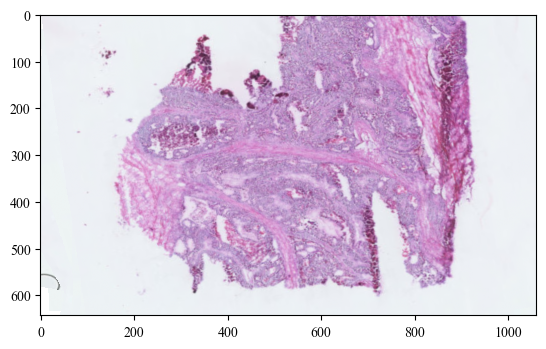

In [2]:
f=h5py.File('./data/Colorectal_Adenocarcinoma.h5','r')
folder_path = './pic/colorectal'
os.makedirs(folder_path, exist_ok=True)

for i in range(1,27,1):
    string='s'+str(i)
    plt.imshow(np.array(f['data'][string]['op']).transpose(1,2,0))
    plt.savefig(f'./pic/colorectal/{string}_op.png',bbox_inches='tight')  
f.close()

## Flatten the raw data from 'Colorectal_Adenocarcinoma.h5'

In [3]:
f=h5py.File('./data/Colorectal_Adenocarcinoma.h5','r')
section_num=26
row=np.array(f['data']['s1']['x']).shape[-2]
col=np.array(f['data']['s1']['x']).shape[-1]
mzList=np.array(f['mz']).reshape(-1)
location=np.zeros(shape=(row*col*section_num,3),dtype=np.int16)
nSpecFeatures = len(mzList)
MSI_train=np.zeros(shape=(row*col*section_num,nSpecFeatures))
TissueIDs = [x for x in range(1,section_num+1,1)]

#for z in range(0,section_num,1):
index=0
for z in range(0,section_num,1):
    spec_data=np.array(f['data']['s'+str(z+1)]['x'])
    for x in range(0,row,1):
        for y in range (0,col,1):
            location[index]=[x,y,z]
            MSI_train[index]=spec_data[:,x,y]
            index+=1

Tic_sum=np.sum(MSI_train,axis=-1)
not_Zero_point=(Tic_sum!=0.)
location=location[not_Zero_point,:]
MSI_train=MSI_train[not_Zero_point,:]
Combined_MSI=(MSI_train/np.sum(MSI_train,axis=-1)[:,None]).astype(np.float32)
XCoord=location[:,0]
YCoord=location[:,1]
ZCoord=location[:,2]
f.close()

## K fold split

Training: [ 1  2  3  6  7  8  9 11 13 14 15 16 17 18 19 20 21 23 24 25] Testing:[ 0  4  5 10 12 22]
Training: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 17 18 21 22 23 24 25] Testing:[ 3 15 16 19 20]
Training: [ 0  1  3  4  5  6  7  8  9 10 12 15 16 18 19 20 21 22 23 24 25] Testing:[ 2 11 13 14 17]
Training: [ 0  2  3  4  5  7  8 10 11 12 13 14 15 16 17 18 19 20 22 23 25] Testing:[ 1  6  9 21 24]
Training: [ 0  1  2  3  4  5  6  9 10 11 12 13 14 15 16 17 19 20 21 22 24] Testing:[ 7  8 18 23 25]


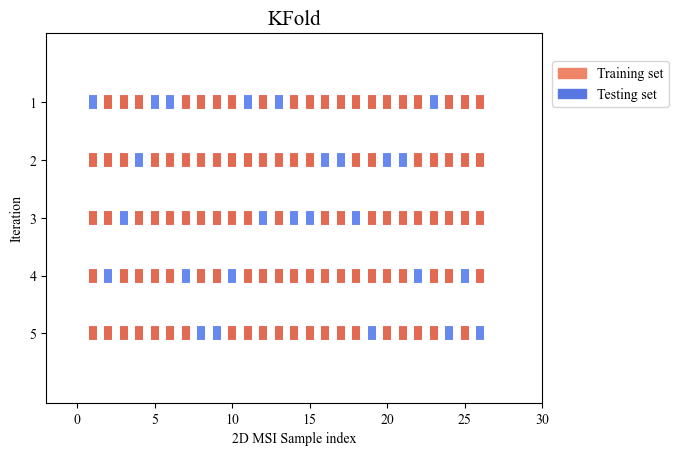

In [4]:
from sklearn.model_selection import  KFold
from matplotlib.patches import Patch
cmap_data = plt.cm.Paired
cmap_cv = plt.cm.coolwarm

n_folds = 5
kfold = KFold(n_folds,  shuffle=True) 
fig, ax = plt.subplots() 
ij_Training = []; ij_Testing = []
if not os.path.exists('CV_Values'):
    os.makedirs('CV_Values')
myHF = h5py.File('CV_Values/cv_Idx.h5', 'w')
for ij, (Train_idx, Test_idx) in enumerate(kfold.split(TissueIDs)):
    print("Training: %s Testing:%s" %(Train_idx, Test_idx))
    ij_Training.append(Train_idx)
    ij_Testing.append(Test_idx)
    myHF.create_dataset('indx_Training'+str(ij), data=Train_idx)
    myHF.create_dataset('indx_Testing'+str(ij), data=Test_idx)   
    
    indices = np.array([np.nan] * len(TissueIDs))
    indices[Train_idx] = 1
    indices[Test_idx] = 0
    ax.scatter(range(1,len(indices)+1), [ij + 1] * len(indices),
               c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-0.2, vmax=1.2)
    yticklabels = list(range(1,n_folds+1))
    ax.set(yticks=np.arange(1,n_folds+1) , yticklabels=yticklabels,
           xlabel='2D MSI Sample index', ylabel="Iteration",
           ylim=[n_folds+1.2,-.2], xlim=[-2, len(TissueIDs)+4])
    ax.set_title('KFold', fontsize=15)

ax.legend([Patch(color=cmap_cv(.8)), Patch(color=cmap_cv(.1))],
['Training set', 'Testing set'], loc=(1.02, .8))
myHF.close()

## Training Process

Model Training ...>>>......


C:\Users\Amfe\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch:0 Training Loss:6.878511381930992 Testing loss:5.513598057261684 Time/epoch:3.0685653686523438s
Epoch:1 Training Loss:5.3009382805537655 Testing loss:5.0736966467740245 Time/epoch:2.68019700050354s
Epoch:2 Training Loss:5.062219406086239 Testing loss:4.985428341648035 Time/epoch:2.4010872840881348s
Epoch:3 Training Loss:5.015164346642833 Testing loss:4.973783350827401 Time/epoch:2.4236373901367188s
Epoch:4 Training Loss:5.002736172389463 Testing loss:4.967838931501958 Time/epoch:2.5030200481414795s
Epoch:5 Training Loss:4.999349143335728 Testing loss:4.958118815171091 Time/epoch:2.5083558559417725s
Epoch:6 Training Loss:4.998141231432639 Testing loss:4.9635950640628215 Time/epoch:2.3767497539520264s
Epoch:7 Training Loss:4.998340976694243 Testing loss:4.963086864404511 Time/epoch:2.3878860473632812s
Epoch:8 Training Loss:5.0011198090725255 Testing loss:4.969046684733608 Time/epoch:2.6533315181732178s
Epoch:9 Training Loss:5.002925091102475 Testing loss:4.969223900845177 Time/epoc

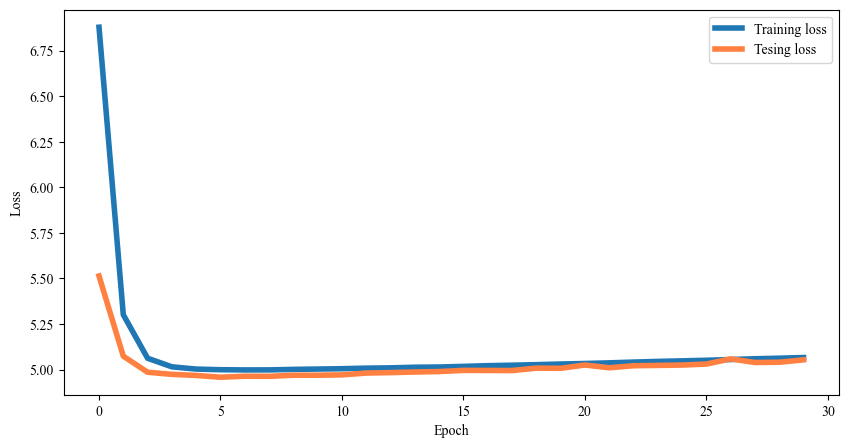

Restruct forward computing time (encoding+2*decoding):12.346644878387451s
mean squared error(mse)  =  2.210531420132611e-07


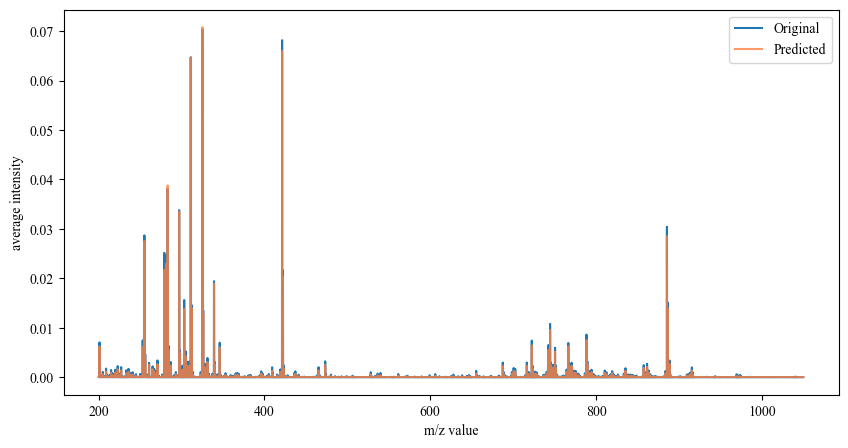

Restruct forward computing time (encoding+2*decoding):3.7165722846984863s
mean squared error(mse)  =  3.470949252459832e-07


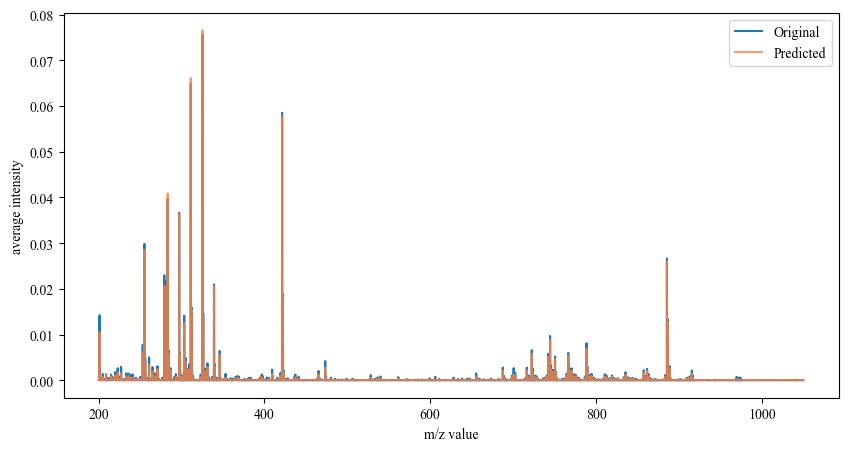

C:\Users\Amfe\AppData\Roaming\Python\Python310\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch:0 Training Loss:6.724448621581873 Testing loss:5.521947799844945 Time/epoch:2.9489800930023193s
Epoch:1 Training Loss:5.23877510011505 Testing loss:5.109125786639274 Time/epoch:2.4215502738952637s
Epoch:2 Training Loss:5.029543782762913 Testing loss:5.0404322096642025 Time/epoch:2.3471884727478027s
Epoch:3 Training Loss:4.990775459170959 Testing loss:5.016567544734224 Time/epoch:2.344780921936035s
Epoch:4 Training Loss:4.979995522474378 Testing loss:5.012350528798205 Time/epoch:2.522918462753296s
Epoch:5 Training Loss:4.978716973813704 Testing loss:5.02728928910925 Time/epoch:2.4222991466522217s
Epoch:6 Training Loss:4.978173097798244 Testing loss:5.0156556900511395 Time/epoch:2.3751134872436523s
Epoch:7 Training Loss:4.979610771712862 Testing loss:5.017344829883982 Time/epoch:2.543757677078247s
Epoch:8 Training Loss:4.980814938718173 Testing loss:5.023754728601334 Time/epoch:2.4894943237304688s
Epoch:9 Training Loss:4.984408232832202 Testing loss:5.036221788284626 Time/epoch:2.3

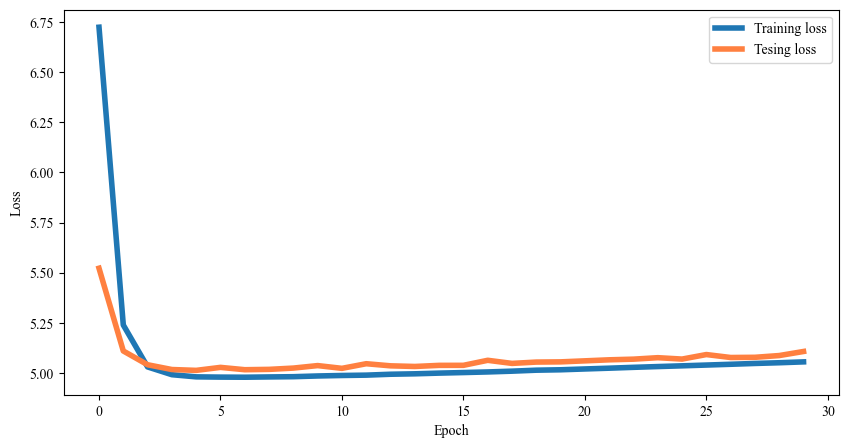

Restruct forward computing time (encoding+2*decoding):12.912580013275146s
mean squared error(mse)  =  3.1092537255972275e-07


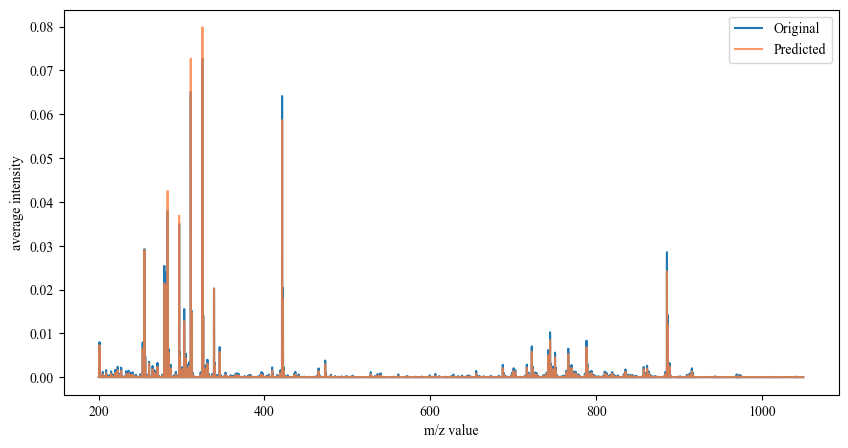

Restruct forward computing time (encoding+2*decoding):3.1207492351531982s
mean squared error(mse)  =  2.9308066018529644e-07


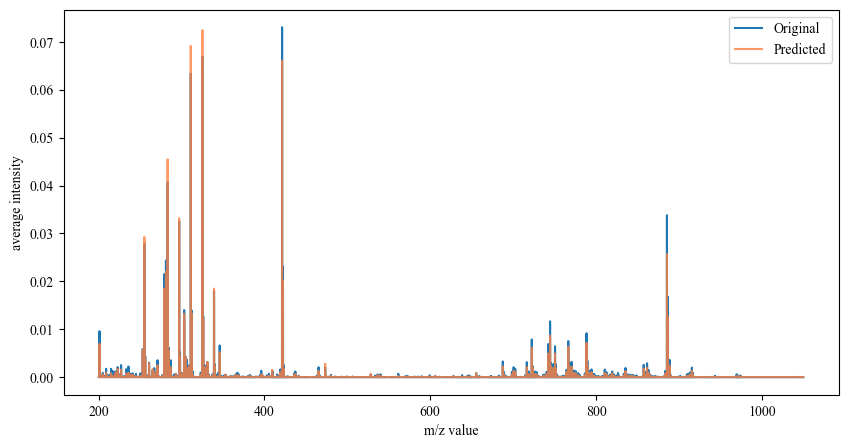

Epoch:0 Training Loss:6.749729458818731 Testing loss:5.563124293866365 Time/epoch:3.0238420963287354s
Epoch:1 Training Loss:5.236953125786536 Testing loss:5.135293234949526 Time/epoch:2.7293622493743896s
Epoch:2 Training Loss:5.026832288073511 Testing loss:5.05814298339512 Time/epoch:2.783186912536621s
Epoch:3 Training Loss:4.988185103406611 Testing loss:5.040224438128264 Time/epoch:2.742682695388794s
Epoch:4 Training Loss:4.977175680632444 Testing loss:5.03790657416634 Time/epoch:2.7034945487976074s
Epoch:5 Training Loss:4.9749077497069365 Testing loss:5.032785643701968 Time/epoch:2.651188611984253s
Epoch:6 Training Loss:4.974885866814053 Testing loss:5.0358971720156465 Time/epoch:2.5906975269317627s
Epoch:7 Training Loss:4.976455322245962 Testing loss:5.039217990377675 Time/epoch:2.445462465286255s
Epoch:8 Training Loss:4.979151801964671 Testing loss:5.039299892342609 Time/epoch:2.5112597942352295s
Epoch:9 Training Loss:4.980125483778334 Testing loss:5.044187545776367 Time/epoch:2.71

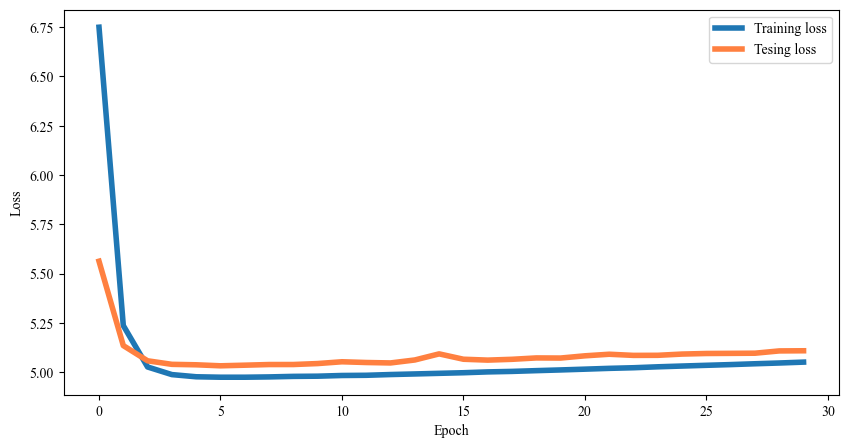

Restruct forward computing time (encoding+2*decoding):12.857179641723633s
mean squared error(mse)  =  2.2469085081411322e-07


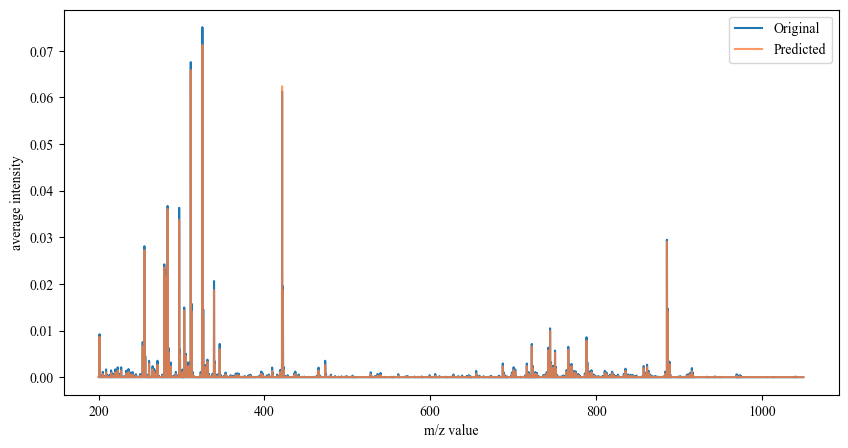

Restruct forward computing time (encoding+2*decoding):3.151993989944458s
mean squared error(mse)  =  2.907910356952925e-07


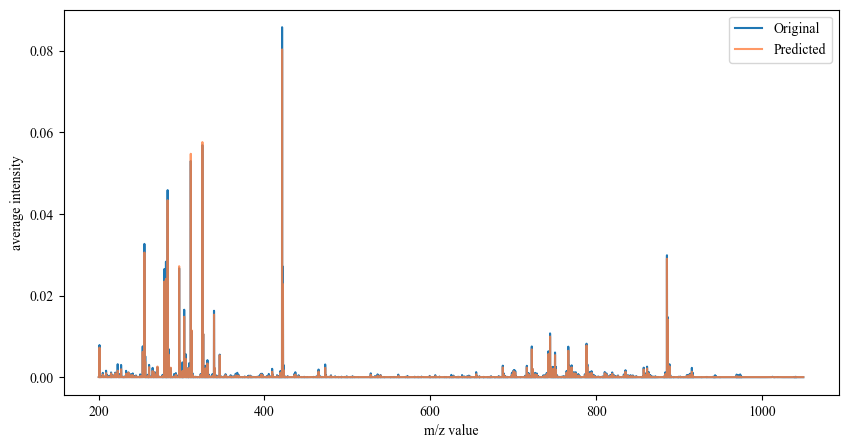

Epoch:0 Training Loss:6.815139071146647 Testing loss:5.4649364047580296 Time/epoch:2.9390225410461426s
Epoch:1 Training Loss:5.244244057092911 Testing loss:5.0274589856465655 Time/epoch:2.520772695541382s
Epoch:2 Training Loss:5.045017621456048 Testing loss:4.965442869398329 Time/epoch:2.413867235183716s
Epoch:3 Training Loss:5.008114433288574 Testing loss:4.941187434726292 Time/epoch:2.3877317905426025s
Epoch:4 Training Loss:5.000257582542224 Testing loss:4.940501923031277 Time/epoch:2.3924331665039062s
Epoch:5 Training Loss:4.998312453734569 Testing loss:4.962505065070259 Time/epoch:2.5525550842285156s
Epoch:6 Training Loss:4.997725719060654 Testing loss:4.940625264909532 Time/epoch:2.4358458518981934s
Epoch:7 Training Loss:4.998632912758069 Testing loss:4.948410532209608 Time/epoch:2.37998628616333s
Epoch:8 Training Loss:5.001383253244254 Testing loss:4.9499920527140295 Time/epoch:2.477496862411499s
Epoch:9 Training Loss:5.002896215976813 Testing loss:4.9653436130947535 Time/epoch:2

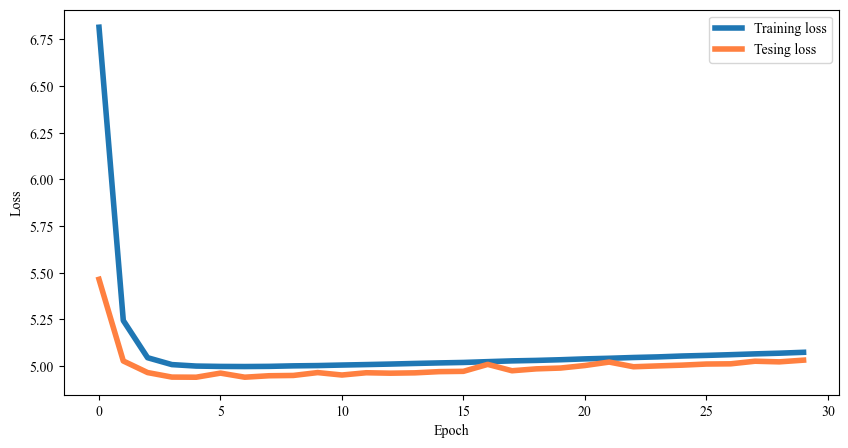

Restruct forward computing time (encoding+2*decoding):13.756438493728638s
mean squared error(mse)  =  2.3207169874694955e-07


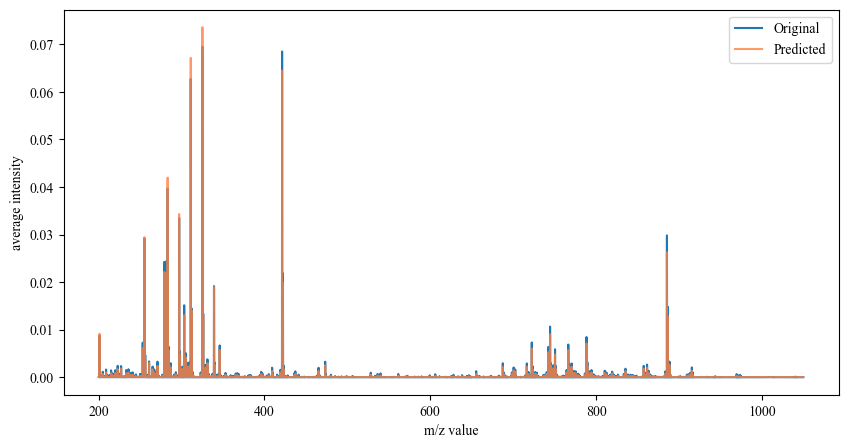

Restruct forward computing time (encoding+2*decoding):3.0286123752593994s
mean squared error(mse)  =  1.8915368116267928e-07


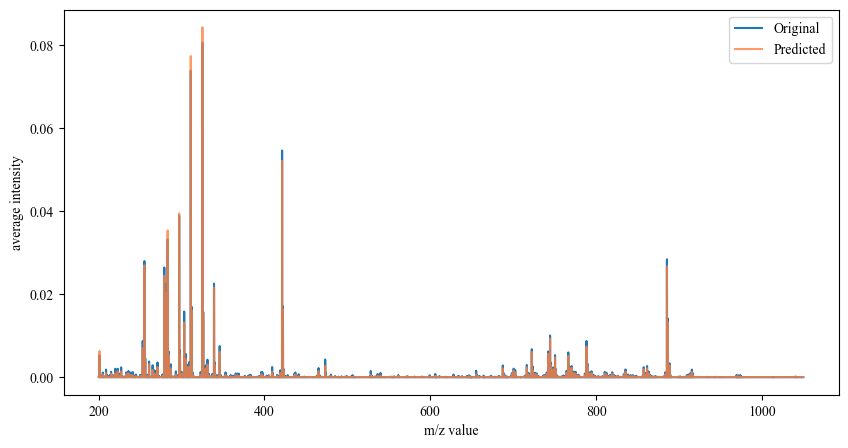

Epoch:0 Training Loss:6.727677104399376 Testing loss:5.4967632915662685 Time/epoch:4.97196364402771s
Epoch:1 Training Loss:5.244868632444401 Testing loss:5.075197976568471 Time/epoch:2.7438881397247314s
Epoch:2 Training Loss:5.042653717945531 Testing loss:5.005199525667273 Time/epoch:2.593446969985962s
Epoch:3 Training Loss:5.004834106288006 Testing loss:4.998124672018963 Time/epoch:2.478468894958496s
Epoch:4 Training Loss:4.996442209814012 Testing loss:4.967930130336596 Time/epoch:2.5695245265960693s
Epoch:5 Training Loss:4.99202169093889 Testing loss:4.961167439170506 Time/epoch:2.421782970428467s
Epoch:6 Training Loss:4.994385294078552 Testing loss:4.992826482524043 Time/epoch:2.446354866027832s
Epoch:7 Training Loss:4.9940017449487115 Testing loss:4.978330529254416 Time/epoch:2.506556749343872s
Epoch:8 Training Loss:4.995999174019725 Testing loss:4.977397400399913 Time/epoch:2.315420627593994s
Epoch:9 Training Loss:4.998739800502345 Testing loss:4.971786851468294 Time/epoch:2.23784

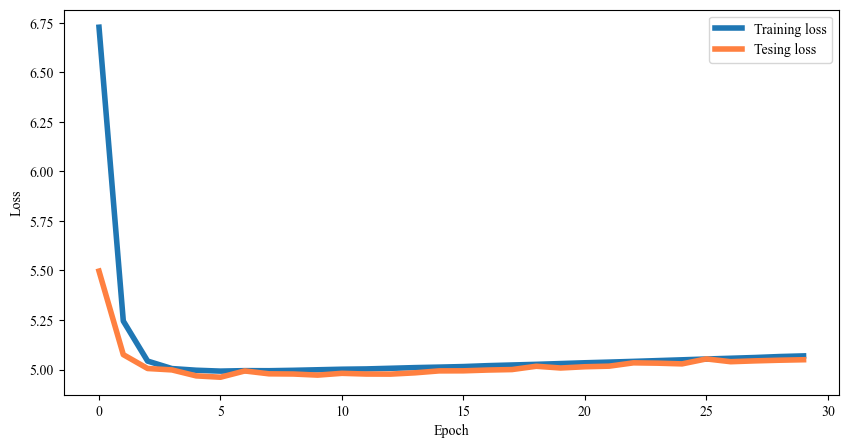

Restruct forward computing time (encoding+2*decoding):13.389505624771118s
mean squared error(mse)  =  2.658924813658814e-07


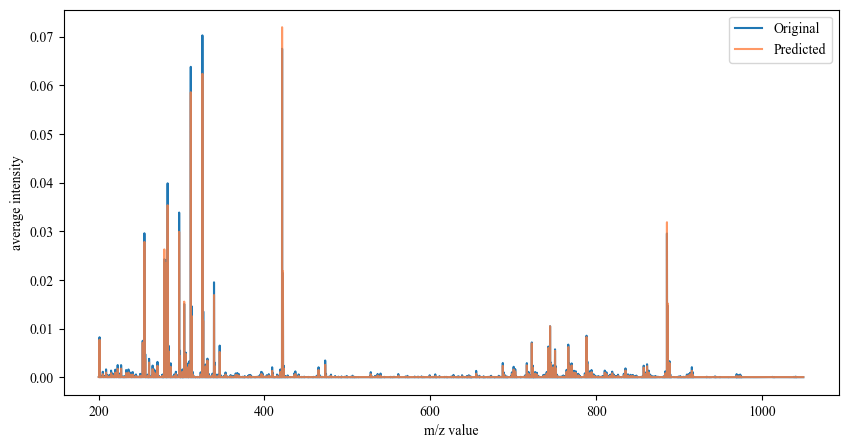

Restruct forward computing time (encoding+2*decoding):3.099268913269043s
mean squared error(mse)  =  2.661620612798288e-07


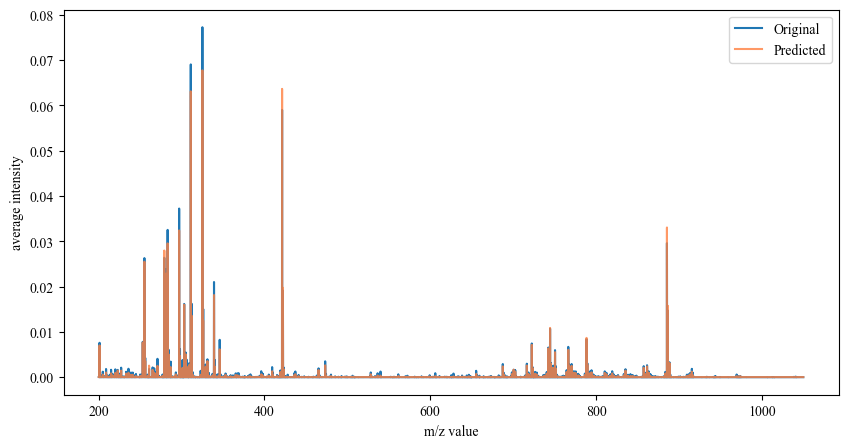

In [5]:
import torch
import Computational_Model_trans
from Computational_Model_trans import *
from importlib import reload
reload(Computational_Model_trans)

import math

batchsize = 512
d_model = 256
lr = 1e-4
epochs = 30
n_head = 8

def Get_cv_MSI(Combined_MSI,XCoord,YCoord,ZCoord,zSections,CV_idx):
    ij_r=[]; ij_t=[]; MSI_train=[]; MSI_Test=[]
    for jr,zr in enumerate(CV_idx):        
        if jr==0:
            ij_r = np.argwhere(ZCoord == zSections[zr])
        else:
            ij_r = np.concatenate((ij_r, np.argwhere(ZCoord == zSections[zr])),axis=0)
    MSI_Data = np.squeeze(Combined_MSI[ij_r,])
    XCoord_cv = XCoord[ij_r]
    YCoord_cv = YCoord[ij_r]
    ZCoord_cv = ZCoord[ij_r]

    return MSI_Data,XCoord_cv,YCoord_cv,ZCoord_cv

zSections = np.unique(ZCoord)
directory = Cd+'/Results_CV'
model_dir = Cd+'/Saved_models'       
os.makedirs(directory,exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

meanSpec_Orig_AllData = np.mean(Combined_MSI,axis=0)

TrainStatus = int(input(
    "0: No Training, 1: Training from random initialized model, 2: Training from previous model: "))
if TrainStatus== 0:
    print('No Training')
else:
    print('Model Training ...>>>......')
hf_cv = h5py.File('CV_Values/cv_Idx.h5', 'r') 
for fold_idx in range(n_folds):
    Train_idx = hf_cv['indx_Training'+str(fold_idx)][:]
    Test_idx = hf_cv['indx_Testing'+str(fold_idx)][:]
    MSI_train,XCoord_cv,YCoord_cv,ZCoord_cv = Get_cv_MSI(Combined_MSI,XCoord,YCoord,ZCoord,zSections,Train_idx)
    MSI_test,XCoord_cv_test,YCoord_cv_test,ZCoord_cv_test = Get_cv_MSI(Combined_MSI,XCoord,YCoord,ZCoord,zSections,Test_idx)
    myzSections = np.unique(ZCoord_cv)

    device=torch.device('cuda')
    train_dataset=MSIdataset(MSI_train,XCoord_cv,YCoord_cv,ZCoord_cv)
    test_dataset=MSIdataset(MSI_test,XCoord_cv_test,YCoord_cv_test,ZCoord_cv_test)
    train_dataloader = torch.utils.data.DataLoader(train_dataset , batch_size=batchsize,
                                          shuffle=True, num_workers=0)
    test_dataloader=torch.utils.data.DataLoader(test_dataset, batch_size=batchsize,
                                          shuffle=True, num_workers=0)
    loss_function=categorical_crossentropy
    model = Model_trans(d_mz=len(mzList), d_model=d_model,
                        encoder_layer_num=1, decoder_layer_num=2, n_head=n_head)
    model.to(device=device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)

    if TrainStatus==0:
        try:
            model.load_state_dict(torch.load(model_dir+f'/TrainedModel_3DColorectal_trans_fold{fold_idx}.h5'))
        except:
            raise TypeError('No previous model found')
    elif TrainStatus==1 or TrainStatus==2:
        if TrainStatus==2:
            try:
                model.load_state_dict(torch.load(
                    model_dir+f'/TrainedModel_3DColorectal_trans_fold{fold_idx}.h5'))
            except:
                raise TypeError('No previous model found')
        for epoch in range(epochs):
            time1=time.time()
            loss_in_train=[]
            model.train()
            for i,(data,_,_,_) in enumerate(train_dataloader):
                data=data.to(device=device)
                loss=loss_function(model(data),data)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                loss_in_train.append(loss.item())
            model.log["training loss"].append(np.mean(loss_in_train))
            model.eval()
            time2=time.time()
            with torch.no_grad():
                loss_in_test=[]
                for i,(data,_,_,_) in enumerate(test_dataloader):
                    data=data.to(device=device)
                    loss=loss_function(model(data),data)
                    loss_in_test.append(loss.item())
                model.log["testing loss"].append(np.mean(loss_in_test))
                
            print(f'Epoch:{epoch} Training Loss:{model.log["training loss"][-1]} \
Testing loss:{model.log["testing loss"][-1]} Time/epoch:{(time2-time1)}s')

        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(epochs),model.log['training loss'],label='Training loss',lw=4)
        plt.plot(np.arange(epochs),model.log['testing loss'],label='Tesing loss',color = [1.0, 0.5, 0.25],lw=4)
        plt.xlabel('Epoch');plt.ylabel('Loss')
        plt.legend()
        plt.show()
        model.eval()
        torch.save(model.state_dict(),model_dir+f'/TrainedModel_3DColorectal_trans_fold{fold_idx}.h5')


    with torch.no_grad():
        encoder=nn.Sequential(model.backbone,model.transformerencoder)
        backbone=model.backbone
        encoder.eval()
        Train_test_package=[[train_dataloader,MSI_train.shape,XCoord_cv.shape,YCoord_cv.shape,ZCoord_cv.shape],
                            [test_dataloader,MSI_test.shape,XCoord_cv_test.shape,YCoord_cv_test.shape,ZCoord_cv_test.shape]]
        model.to(device='cpu')
        for dataloader,MSI_shape,X_shape,Y_shape,Z_shape in (Train_test_package):
            decoded_imgs=torch.zeros(MSI_shape)
            Latent_z=torch.zeros(size=(MSI_shape[0],d_model))
            Previous_z=torch.zeros(size=(MSI_shape[0],d_model))
            X=torch.zeros(X_shape,dtype=torch.int)
            Y=torch.zeros(Y_shape,dtype=torch.int)
            Z=torch.zeros(Z_shape,dtype=torch.int)
            MSI_shuffle=torch.zeros(MSI_shape)
            
            time1=time.time()
            for i,(data,xLoc,yLoc,zLoc) in enumerate(dataloader):
                    decoded_imgs[i*batchsize:i*batchsize+data.shape[0]]=model(data)
                    Latent_z[i*batchsize:i*batchsize+data.shape[0]]=encoder(data)
                    Previous_z[i*batchsize:i*batchsize+data.shape[0]]=backbone(data)
                    X[i*batchsize:i*batchsize+data.shape[0]]=xLoc
                    Y[i*batchsize:i*batchsize+data.shape[0]]=yLoc
                    Z[i*batchsize:i*batchsize+data.shape[0]]=zLoc
                    MSI_shuffle[i*batchsize:i*batchsize+data.shape[0]]=data
            time2=time.time()
            print(f'Restruct forward computing time (encoding+2*decoding):{time2-time1}s')
            mse = nn.MSELoss(reduction='mean')(MSI_shuffle,decoded_imgs)
            print('mean squared error(mse)  = ', mse.item())
            meanSpec_Rec = torch.mean(decoded_imgs,dim=0) 
            meanSpec_Orig = torch.mean(MSI_shuffle,dim=0)
            plt.figure(figsize=(10,5))
            plt.plot(mzList,meanSpec_Orig.detach().numpy(),label='Original',alpha=1); 
            plt.plot(mzList,meanSpec_Rec.detach().numpy(),color = [1.0, 0.5, 0.25],label='Predicted',alpha=0.8); 
            plt.xlabel('m/z value');plt.ylabel('average intensity')
            plt.legend()
            plt.show()
            
hf_cv.close()

# Clustering Analysis

In [6]:
from Computational_Model_trans import *
from tqdm import tqdm
import torch

batchsize = 512
d_model = 256
n_head = 8
device = torch.device('cuda:0')
model_dir = Cd+'/Saved_models'    
model = Model_trans(d_mz=len(mzList), d_model=d_model,
                    encoder_layer_num=1, decoder_layer_num=2, n_head=n_head)
model.load_state_dict(torch.load(model_dir+'\TrainedModel_3DColorectal_trans_fold1.h5'))
encoder=nn.Sequential(model.backbone,model.transformerencoder)
model.eval().to(device)
encoder.eval().to(device)
All_dataset=MSIdataset(Combined_MSI,XCoord,YCoord,ZCoord)
All_dataloader = torch.utils.data.DataLoader(All_dataset , batch_size=batchsize,
                                          shuffle=False, num_workers=0)
num_samples = len(All_dataset)
d_mz_len = len(mzList)
latent_dim = d_model 

all_encoded = torch.empty((num_samples, latent_dim), dtype=torch.float32)
all_decoded = torch.empty((num_samples, d_mz_len), dtype=torch.float32)
all_coords = torch.empty((num_samples, 3), dtype=torch.int16)

model.eval().to(device)
encoder.eval().to(device) 

with torch.no_grad():
    ptr = 0
    for data, xLoc, yLoc, zLoc in tqdm(All_dataloader, desc="Processing", unit="batch"):
        bs = data.size(0)
        data_gpu = data.to(device, non_blocking=True)
        encoded_out = encoder(data_gpu) 
        decoded_out = model(data_gpu)
        
        all_encoded[ptr : ptr + bs] = encoded_out.cpu()
        all_decoded[ptr : ptr + bs] = decoded_out.cpu()
        
        all_coords[ptr : ptr + bs, 0] = xLoc
        all_coords[ptr : ptr + bs, 1] = yLoc
        all_coords[ptr : ptr + bs, 2] = zLoc
        
        ptr += bs

torch.cuda.empty_cache()

decoded_imgs = all_decoded
X = all_coords[:, 0]
Y = all_coords[:, 1]
Z = all_coords[:, 2]

print("Processing complete.")

Processing: 100%|██████████| 240/240 [00:06<00:00, 35.52batch/s]

Processing complete.


C:\Users\Amfe\AppData\Local\Temp\ipykernel_279912\3273618234.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('plasma').copy()


Visualizing 256 feature channels for section Z=3...
Saved to: ./pic/colorectal/latent_viz/section_4_all_channels_bluepurple_test.png


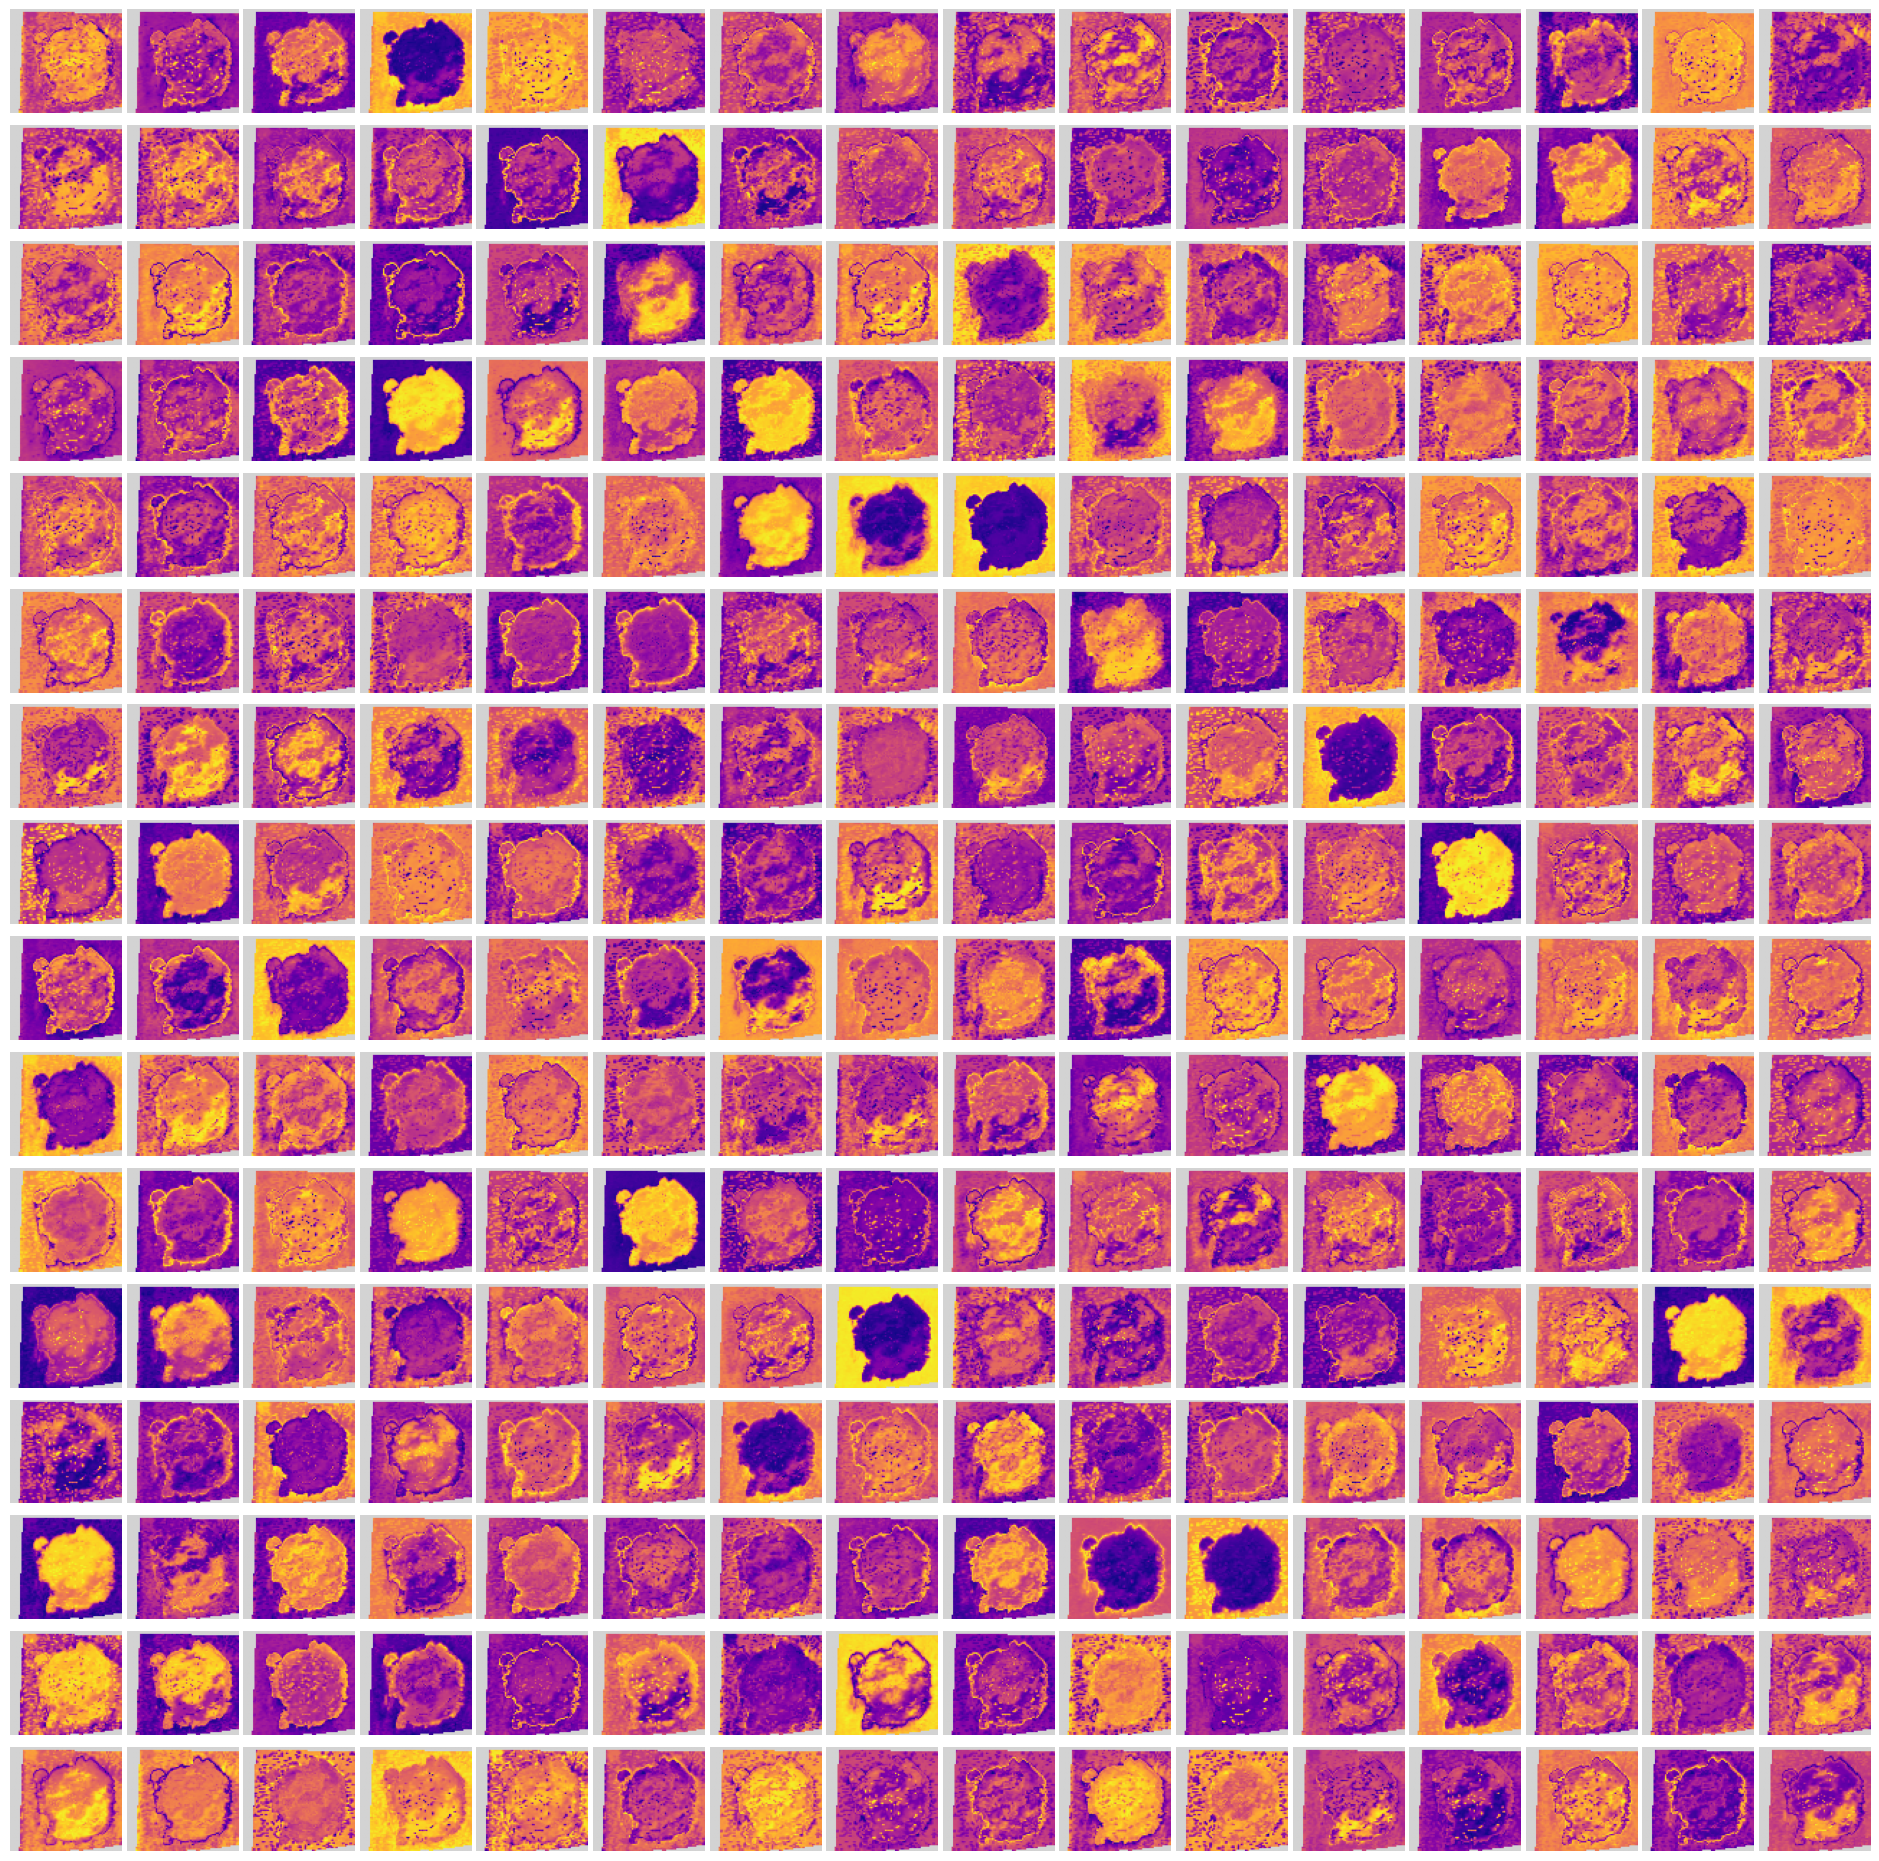

In [7]:
import matplotlib.pyplot as plt
import numpy as np

if isinstance(X, torch.Tensor):
    X_viz = X.cpu().numpy()
    Y_viz = Y.cpu().numpy()
    Z_viz = Z.cpu().numpy()
    feats_viz = all_encoded 
else:
    X_viz = X
    Y_viz = Y
    Z_viz = Z
    feats_viz = all_encoded

first_z = np.unique(Z_viz)[3]
print(f"Visualizing 256 feature channels for section Z={first_z}...")

idx_mask = (Z_viz == first_z)
x_slice = X_viz[idx_mask]
y_slice = Y_viz[idx_mask]
feats_slice = feats_viz[idx_mask]
cmap = plt.cm.get_cmap('plasma').copy() 
cmap.set_bad(color='lightgray') 

img_h, img_w = row, col 

fig, axes = plt.subplots(16, 16, figsize=(24, 24))
axes = axes.flatten()

for i in range(256):
    ax = axes[i]
    
    img_data = np.full((img_h, img_w), np.nan)
    
    try:
        img_data[x_slice, y_slice] = feats_slice[:, i]
    except IndexError:
        img_data[x_slice-1, y_slice-1] = feats_slice[:, i]

    ax.imshow(img_data, cmap=cmap)
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)

os.makedirs('./pic/colorectal/latent_viz', exist_ok=True)
save_path = f'./pic/colorectal/latent_viz/section_{first_z+1}_all_channels_bluepurple_test.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to: {save_path}")
plt.show()

In [8]:
import math

nClusters = 5
all_encoded_np = all_encoded.numpy() if hasattr(all_encoded, 'numpy') else np.array(all_encoded)
X_np = X.numpy().flatten() if hasattr(X, 'numpy') else np.array(X).flatten()
Y_np = Y.numpy().flatten() if hasattr(Y, 'numpy') else np.array(Y).flatten()
Z_np = Z.numpy().flatten() if hasattr(Z, 'numpy') else np.array(Z).flatten()

gmm = GaussianMixture(n_components=nClusters, covariance_type='full', random_state=1337)
Labels = gmm.fit_predict(all_encoded_np)
print(f"GMM fitted with {nClusters} clusters. Label counts: {np.bincount(Labels)}")


C:\Users\Amfe\AppData\Roaming\Python\Python310\site-packages\sklearn\mixture\_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


GMM fitted with 5 clusters. Label counts: [17217 32300 34887 24276 13808]


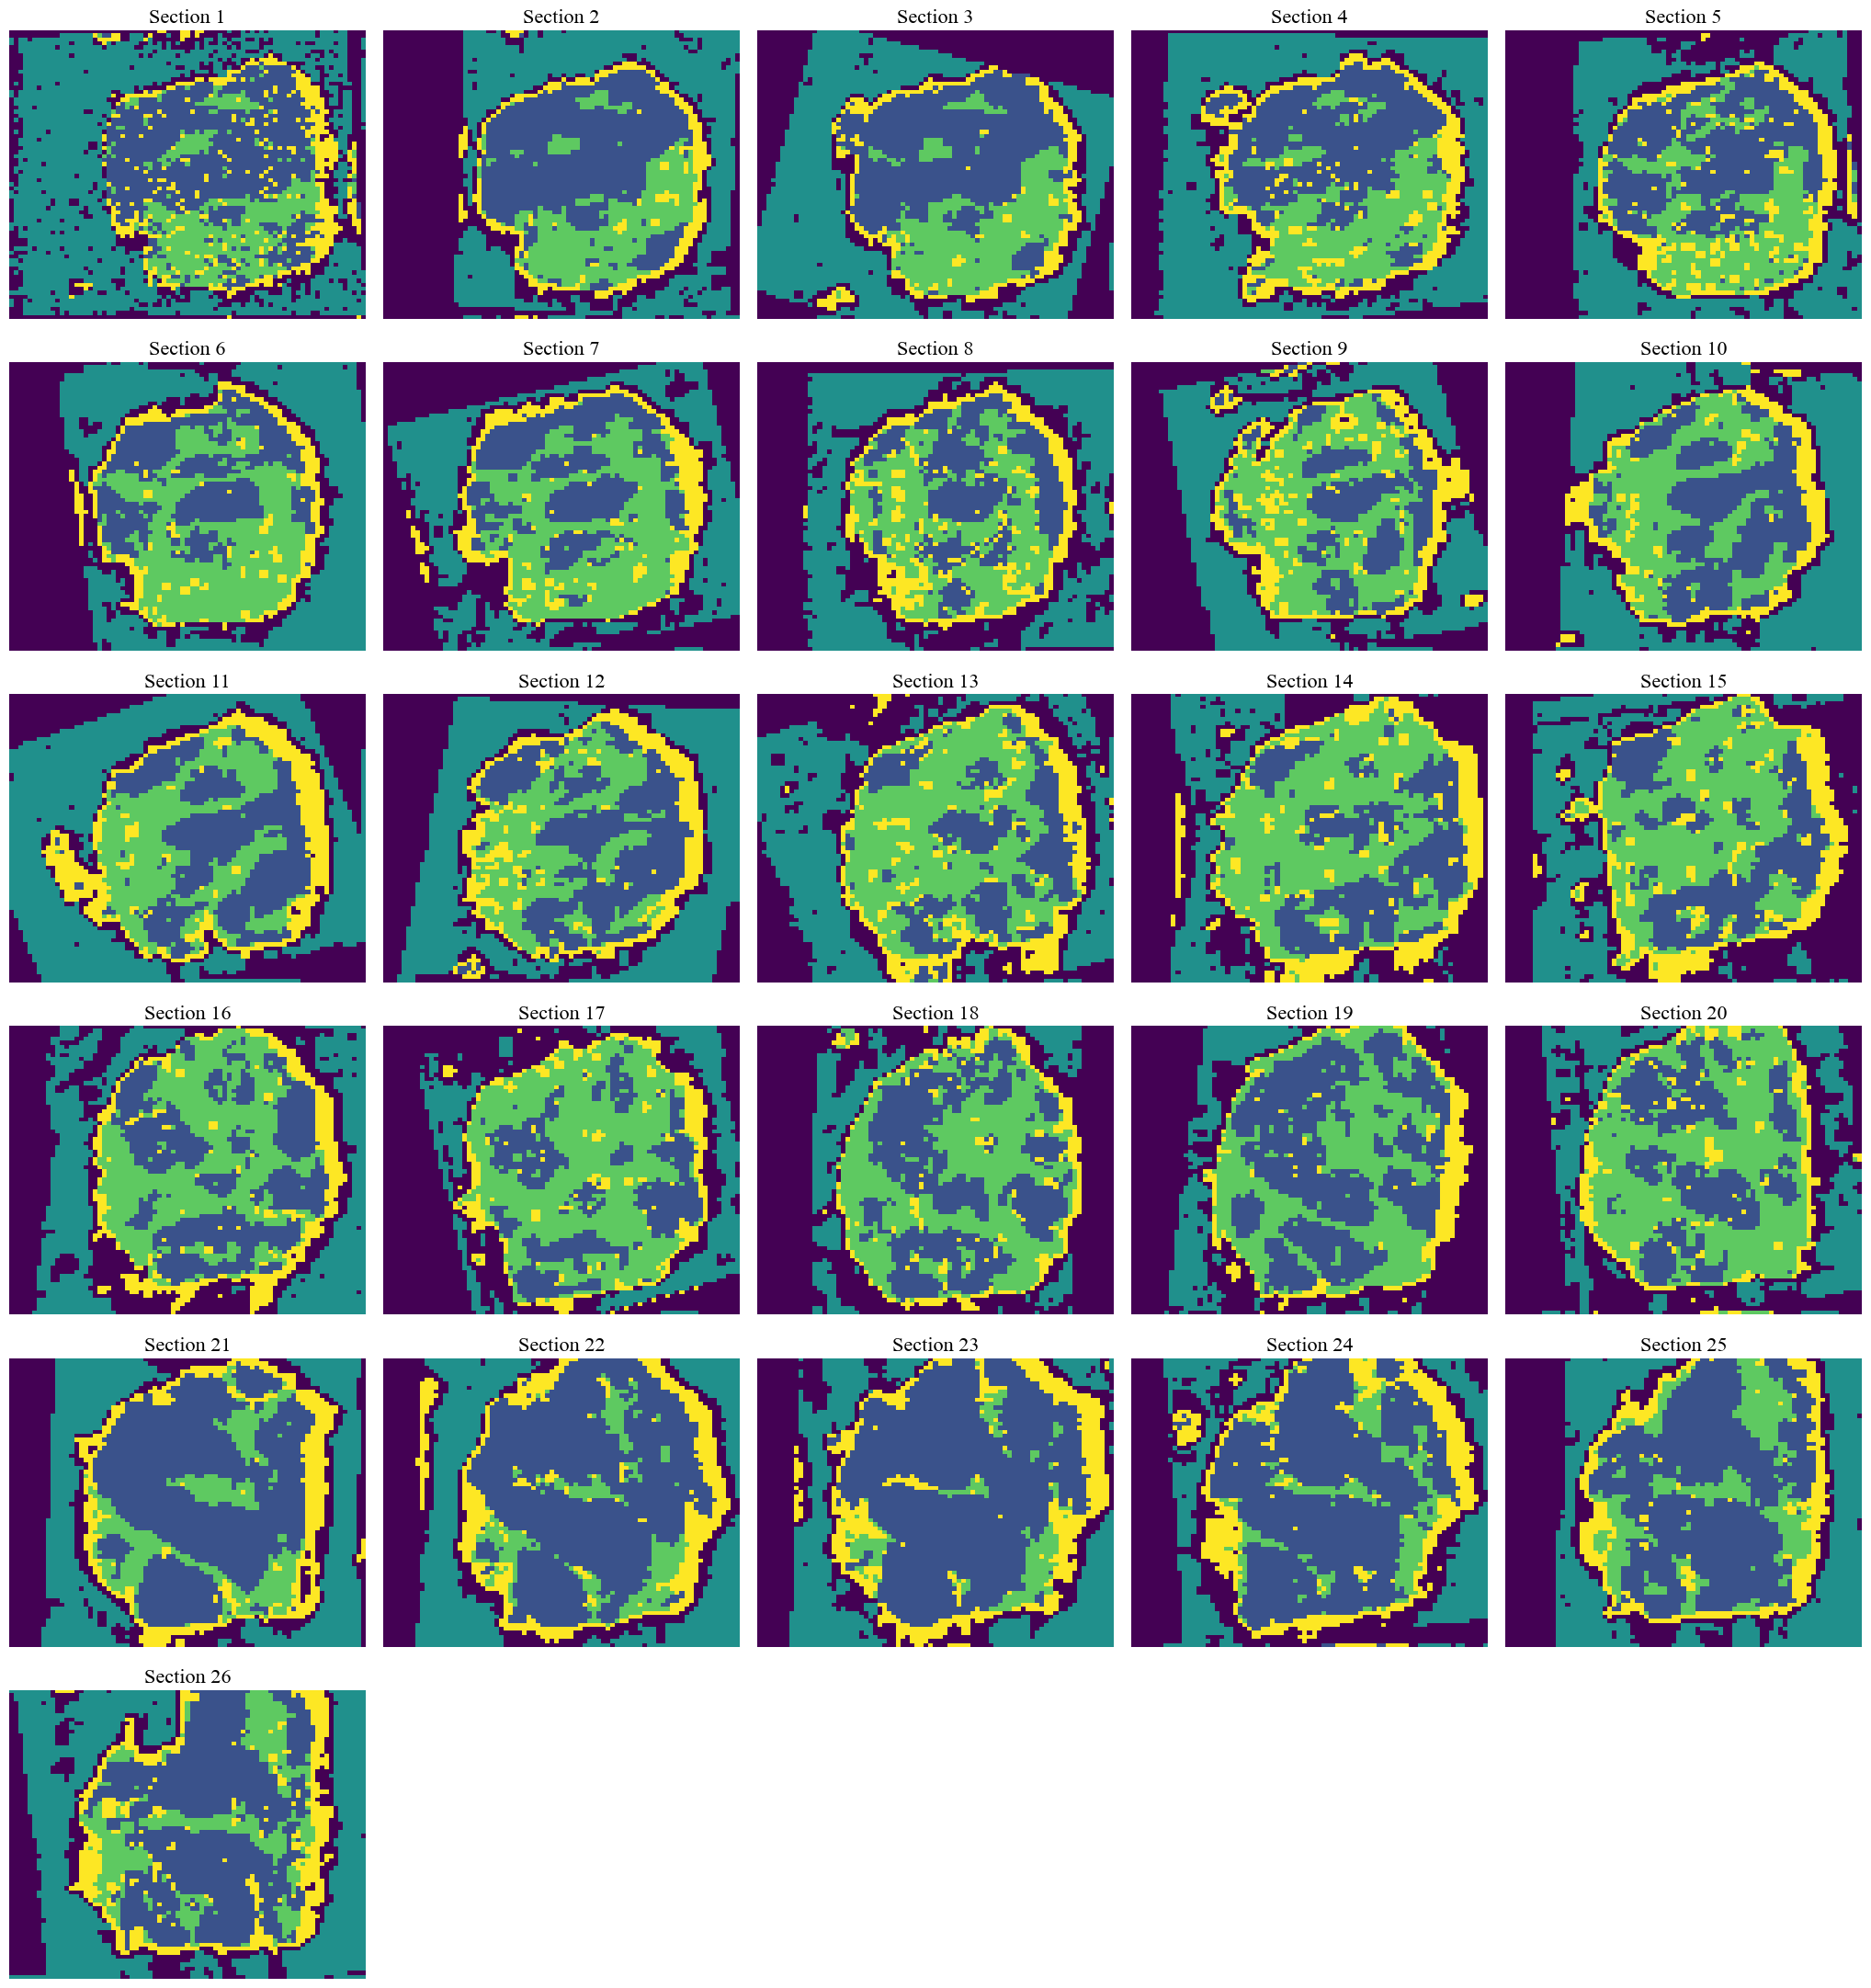

In [9]:
myzSections = np.unique(Z_np)
n_sections = len(myzSections)
ncols = 5
nrows = math.ceil(n_sections / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.2, nrows * 3.8))
axes = axes.flatten()

for i, section_id in enumerate(myzSections):
    ax = axes[i]
    ij_r = np.argwhere(Z_np == section_id)
    indx = ij_r[:, 0]
    xLoc = X_np[indx]
    yLoc = Y_np[indx]
    section_labels = Labels[indx]

    im = Image_Distribution(section_labels, xLoc, yLoc)
    ax.imshow(im, aspect='auto')
    ax.set_title(f'Section {int(section_id) + 1}', fontsize=16)
    ax.axis('off')

for j in range(n_sections, len(axes)):
    axes[j].axis('off')

fig.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.02, wspace=0.05, hspace=0.15)

os.makedirs('./pic/colorectal', exist_ok=True)
plt.savefig('./pic/colorectal/gmm_all_sections.png', dpi=300, bbox_inches='tight')
plt.show()
